In [1]:
!pip install -q schedulefree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 577.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 38.1 MB/s eta 0:00:00


In [2]:
import os
import pickle
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib import pyplot as plt
from schedulefree import RAdamScheduleFree
from scipy.spatial.transform import Rotation as R
from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary

In [3]:
def seed_everything(seed):
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.use_deterministic_algorithms(True)


seed_everything(0)

## 0. Setting

In [4]:
INPUT_DIR = "/kaggle/input/cmi-detect-behavior-with-sensor-data"
SEGMENTATION_DIR = "/kaggle/input/cmi3-1-gesture-segmentation"
MODEL_DIR = "./"
OUTPUT_DIR = "./"

In [5]:
@dataclass
class Config:
    seq_len: int = 75
    n_splits: int = 10
    n_seeds: int = 5
    n_epochs: int = 15
    batch_size: int = 32
    lr: float = 5e-3
    betas: tuple[float, float] = (0.9, 0.999)
    label_smoothing: float = 0.1
    aux_loss_weight: float = 0.5


config = Config()

## 1. Preprocessing

In [6]:
class Preprocessor:
    def __init__(self):
        self.scaler = StandardScaler()
        self.scaler.set_output(transform="pandas")

    def _add_linear_acc(self, df: pl.DataFrame) -> pl.DataFrame:
        acc_values = df.select(["acc_x", "acc_y", "acc_z"]).to_numpy()
        quat_values = df.select(["rot_x", "rot_y", "rot_z", "rot_w"]).to_numpy()
        linear_acc_values = np.full_like(acc_values, np.nan)
        gravity_world = np.array([0, 0, 9.81])
        for i in range(len(df)):
            if np.all(np.isnan(quat_values[i])):
                continue
            rotation = R.from_quat(quat_values[i])
            gravity_values = rotation.apply(gravity_world, inverse=True)
            linear_acc_values[i, :] = acc_values[i, :] - gravity_values

        df_add = pl.DataFrame(linear_acc_values, schema=["linear_acc_x", "linear_acc_y", "linear_acc_z"]).fill_nan(None)
        df = pl.concat([df, df_add], how="horizontal")

        return df

    def _add_rotvec_diff(self, df: pl.DataFrame) -> pl.DataFrame:
        ids = df.select("sequence_id").to_series().to_numpy()
        quat_values = df.select(["rot_x", "rot_y", "rot_z", "rot_w"]).to_numpy()
        rotvec_diff_values = np.full((len(df), 3), np.nan)
        for i in range(1, len(df)):
            if ids[i - 1] != ids[i]:
                continue
            q1 = quat_values[i - 1]
            q2 = quat_values[i]
            if np.all(np.isnan(q1)) or np.all(np.isnan(q2)):
                continue
            rot1 = R.from_quat(q1)
            rot2 = R.from_quat(q2)
            rotvec_diff_values[i, :] = (rot1.inv() * rot2).as_rotvec()

        df_add = pl.DataFrame(rotvec_diff_values, schema=["rotvec_diff_x", "rotvec_diff_y", "rotvec_diff_z"]).fill_nan(None)
        df = pl.concat([df, df_add], how="horizontal")

        return df

    def _cancel_z_rotation(self, df: pl.DataFrame) -> pl.DataFrame:
        quat_values = df.select(["rot_x", "rot_y", "rot_z", "rot_w"]).to_numpy()
        rotate_flags = df.select("rotate").to_series().to_numpy()
        for i in range(len(df)):
            if np.all(np.isnan(quat_values[i])):
                continue
            rotation = R.from_rotvec([0, 0, 130 + 180 * rotate_flags[i]], degrees=True) * R.from_quat(quat_values[i])
            quat_values[i, :] = rotation.as_quat(canonical=True, scalar_first=True)

        df_add = pl.DataFrame(quat_values, schema=["rot_w", "rot_x", "rot_y", "rot_z"]).fill_nan(None)
        df = pl.concat([df.drop(["rot_w", "rot_x", "rot_y", "rot_z"]), df_add], how="horizontal")

        return df

    def _add_global_acc(self, df: pl.DataFrame) -> pl.DataFrame:
        acc_values = df.select(["acc_x", "acc_y", "acc_z"]).to_numpy()
        quat_values = df.select(["rot_x", "rot_y", "rot_z", "rot_w"]).to_numpy()
        global_acc_values = np.full_like(acc_values, np.nan)
        for i in range(len(df)):
            if np.all(np.isnan(quat_values[i])):
                continue
            rotation = R.from_quat(quat_values[i])
            global_acc_values[i, :] = rotation.apply(acc_values[i, :])

        df_add = pl.DataFrame(global_acc_values, schema=["global_acc_x", "global_acc_y", "global_acc_z"]).fill_nan(None)
        df = pl.concat([df, df_add], how="horizontal")

        return df

    def _handle_left_handed(self, df: pl.DataFrame) -> pl.DataFrame:
        df = (
            df.with_columns(
                *[
                    pl.when(pl.col("handedness") == 0).then(-pl.col(col)).otherwise(pl.col(col)).alias(col)
                    for col in [
                        "acc_x",
                        "linear_acc_x",
                        "global_acc_x",
                        "rot_y",
                        "rot_z",
                        "rotvec_diff_y",
                        "rotvec_diff_z",
                    ]
                ],
            )
            .with_columns(
                pl.when(pl.col("handedness") == 0).then(pl.col("thm_5")).otherwise(pl.col("thm_3")).alias("thm_3"),
                pl.when(pl.col("handedness") == 0).then(pl.col("thm_3")).otherwise(pl.col("thm_5")).alias("thm_5"),
                *[
                    pl.when(pl.col("handedness") == 0)
                    .then(pl.col(f"tof_5_v{i}"))
                    .otherwise(pl.col(f"tof_3_v{i}"))
                    .alias(f"tof_3_v{i}")
                    for i in range(64)
                ],
                *[
                    pl.when(pl.col("handedness") == 0)
                    .then(pl.col(f"tof_3_v{i}"))
                    .otherwise(pl.col(f"tof_5_v{i}"))
                    .alias(f"tof_5_v{i}")
                    for i in range(64)
                ],
            )
            .with_columns(
                *[
                    pl.when(pl.col("handedness") == 0)
                    .then(pl.col(f"tof_{i}_v{8 * j + 7 - k}"))
                    .otherwise(pl.col(f"tof_{i}_v{8 * j + k}"))
                    .alias(f"tof_{i}_v{8 * j + k}")
                    for i in range(1, 6)
                    for j in range(8)
                    for k in range(8)
                ],
            )
        )

        return df

    def _handle_rotated_device(self, df: pl.DataFrame) -> pl.DataFrame:
        df = (
            df.with_columns(
                *[
                    pl.when(pl.col("rotate") == 1).then(-pl.col(col)).otherwise(pl.col(col)).alias(col)
                    for col in [
                        "acc_x",
                        "acc_y",
                        "linear_acc_x",
                        "linear_acc_y",
                        "global_acc_x",
                        "global_acc_y",
                        "rot_x",
                        "rot_y",
                        "rotvec_diff_x",
                        "rotvec_diff_y",
                    ]
                ],
            )
            .with_columns(
                pl.when(pl.col("rotate") == 1).then(pl.col("thm_4")).otherwise(pl.col("thm_2")).alias("thm_2"),
                pl.when(pl.col("rotate") == 1).then(pl.col("thm_2")).otherwise(pl.col("thm_4")).alias("thm_4"),
                pl.when(pl.col("rotate") == 1).then(pl.col("thm_5")).otherwise(pl.col("thm_3")).alias("thm_3"),
                pl.when(pl.col("rotate") == 1).then(pl.col("thm_3")).otherwise(pl.col("thm_5")).alias("thm_5"),
                *[
                    pl.when(pl.col("rotate") == 1)
                    .then(pl.col(f"tof_4_v{i}"))
                    .otherwise(pl.col(f"tof_2_v{i}"))
                    .alias(f"tof_2_v{i}")
                    for i in range(64)
                ],
                *[
                    pl.when(pl.col("rotate") == 1)
                    .then(pl.col(f"tof_2_v{i}"))
                    .otherwise(pl.col(f"tof_4_v{i}"))
                    .alias(f"tof_4_v{i}")
                    for i in range(64)
                ],
                *[
                    pl.when(pl.col("rotate") == 1)
                    .then(pl.col(f"tof_5_v{i}"))
                    .otherwise(pl.col(f"tof_3_v{i}"))
                    .alias(f"tof_3_v{i}")
                    for i in range(64)
                ],
                *[
                    pl.when(pl.col("rotate") == 1)
                    .then(pl.col(f"tof_3_v{i}"))
                    .otherwise(pl.col(f"tof_5_v{i}"))
                    .alias(f"tof_5_v{i}")
                    for i in range(64)
                ],
            )
            .with_columns(
                *[
                    pl.when(pl.col("rotate") == 1)
                    .then(pl.col(f"tof_{i}_v{63 - j}"))
                    .otherwise(pl.col(f"tof_{i}_v{j}"))
                    .alias(f"tof_{i}_v{j}")
                    for i in range(1, 6)
                    for j in range(64)
                ],
            )
        )

        return df

    def preprocess(self, df: pl.DataFrame) -> pl.DataFrame:
        if "rotate" not in df.columns:
            df = df.with_columns(pl.lit(0).alias("rotate"))

        df = self._add_linear_acc(df)
        df = self._add_rotvec_diff(df)
        df = self._cancel_z_rotation(df)
        df = self._add_global_acc(df)
        df = self._handle_left_handed(df)
        df = self._handle_rotated_device(df)

        # other preprocessing
        df = df.with_columns(
            pl.col("^thm_.*$").clip(lower_bound=20).replace({20: None}),
            pl.col("^tof_._v.*$").replace({-1: 255}),
        )

        return df

    def _get_reversed_sequence_tail(self, df: pl.DataFrame, seq_len: int) -> pl.DataFrame:
        df_tail = (
            df.sort(["sequence_id", "sequence_counter"], descending=[False, True])
            .group_by("sequence_id", maintain_order=True)
            .head(seq_len)
            .with_columns(pl.col("sequence_counter").cum_count().over("sequence_id"))
        )

        return df_tail

    def get_feature_array(self, df: pl.DataFrame, list_features: list, seq_len: int, fit: bool = False) -> np.ndarray:
        df_tail = self._get_reversed_sequence_tail(df, seq_len)
        if fit:
            self.scaler.fit(df_tail.select(list_features))
        df_tail = df_tail.to_pandas()
        df_tail[list_features] = self.scaler.transform(df_tail[list_features])
        df_tail = pl.from_pandas(df_tail).fill_null(0.0)

        feature_arrays = []
        for _, df_group in df_tail.group_by("sequence_id", maintain_order=True):
            array = df_group.select(list_features).to_numpy().T
            array = np.pad(array, ((0, 0), (0, seq_len - array.shape[-1])))
            feature_arrays.append(array)

        return np.stack(feature_arrays, axis=0)

In [7]:
target_gestures = [
    "Above ear - pull hair",
    "Cheek - pinch skin",
    "Eyebrow - pull hair",
    "Eyelash - pull hair",
    "Forehead - pull hairline",
    "Forehead - scratch",
    "Neck - pinch skin",
    "Neck - scratch",
]
non_target_gestures = [
    "Write name on leg",
    "Wave hello",
    "Glasses on/off",
    "Text on phone",
    "Write name in air",
    "Feel around in tray and pull out an object",
    "Scratch knee/leg skin",
    "Pull air toward your face",
    "Drink from bottle/cup",
    "Pinch knee/leg skin",
]
all_gestures = target_gestures + non_target_gestures
dict_gestures = {v: i for i, v in enumerate(all_gestures)}

In [8]:
df = pl.read_csv(f"{INPUT_DIR}/train.csv")
df_demo = pl.read_csv(f"{INPUT_DIR}/train_demographics.csv")
df = df.join(df_demo, on="subject", how="left")

In [9]:
subjects_rotated = ["SUBJ_019262", "SUBJ_045235"]
df = df.with_columns(pl.col("subject").is_in(subjects_rotated).cast(pl.Int16).alias("rotate"))

In [10]:
pp = Preprocessor()
df = pp.preprocess(df)

In [11]:
n_imu_blocks = 4
feature_blocks_except_tof = [
    ["acc_x", "acc_y", "acc_z"],
    ["rot_w", "rot_x", "rot_y", "rot_z"],
    ["linear_acc_x", "linear_acc_y", "linear_acc_z", "global_acc_x", "global_acc_y", "global_acc_z"],
    ["rotvec_diff_x", "rotvec_diff_y", "rotvec_diff_z"],
    ["thm_1", "thm_2", "thm_3", "thm_4", "thm_5"],
]
list_features = sum(feature_blocks_except_tof, []) + [f"tof_{i}_v{j}" for i in range(1, 6) for j in range(64)]

In [12]:
X = pp.get_feature_array(df, list_features, seq_len=config.seq_len, fit=True)
with open(f"{MODEL_DIR}/preprocessor.pickle", "wb") as f:
    pickle.dump(pp, f)

# predicted gesture segment: gesture = 1, non-gesture = -1, padding = 0
gesture_segment = np.load(f"{SEGMENTATION_DIR}/gesture_segment.npy")
gesture_segment = (gesture_segment[:, np.newaxis, : config.seq_len] * 2 - 1) * (X != 0).max(axis=1, keepdims=True)

X = np.concatenate([gesture_segment, X], axis=1)
X, X_tof = X[:, :-320], X[:, -320:]
X_tof = X_tof.transpose(0, 2, 1)
X_tof = X_tof.reshape(X_tof.shape[0], X_tof.shape[1], 5, 8, 8)  # shape: (n_sequence, seq_len, 5, 8, 8)
print(X.shape, X_tof.shape)

(8151, 22, 75) (8151, 75, 5, 8, 8)


In [13]:
orientations = sorted(df["orientation"].unique())
dict_orientations = {v: i for i, v in enumerate(orientations)}

In [14]:
Y_main = (
    df.select(["sequence_id", "gesture"])
    .unique(maintain_order=True)
    .select(pl.col("gesture").replace(dict_gestures).cast(pl.Int8))
    .to_series()
    .to_numpy()
)
Y_aux = (
    df.select(["sequence_id", "orientation"])
    .unique(maintain_order=True)
    .select(pl.col("orientation").replace(dict_orientations).cast(pl.Int8))
    .to_series()
    .to_numpy()
)
Y = np.stack([Y_main, Y_aux], axis=1)
groups = df.select(["sequence_id", "subject"]).unique(maintain_order=True).select("subject").to_series().to_numpy()

/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:825: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:826: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


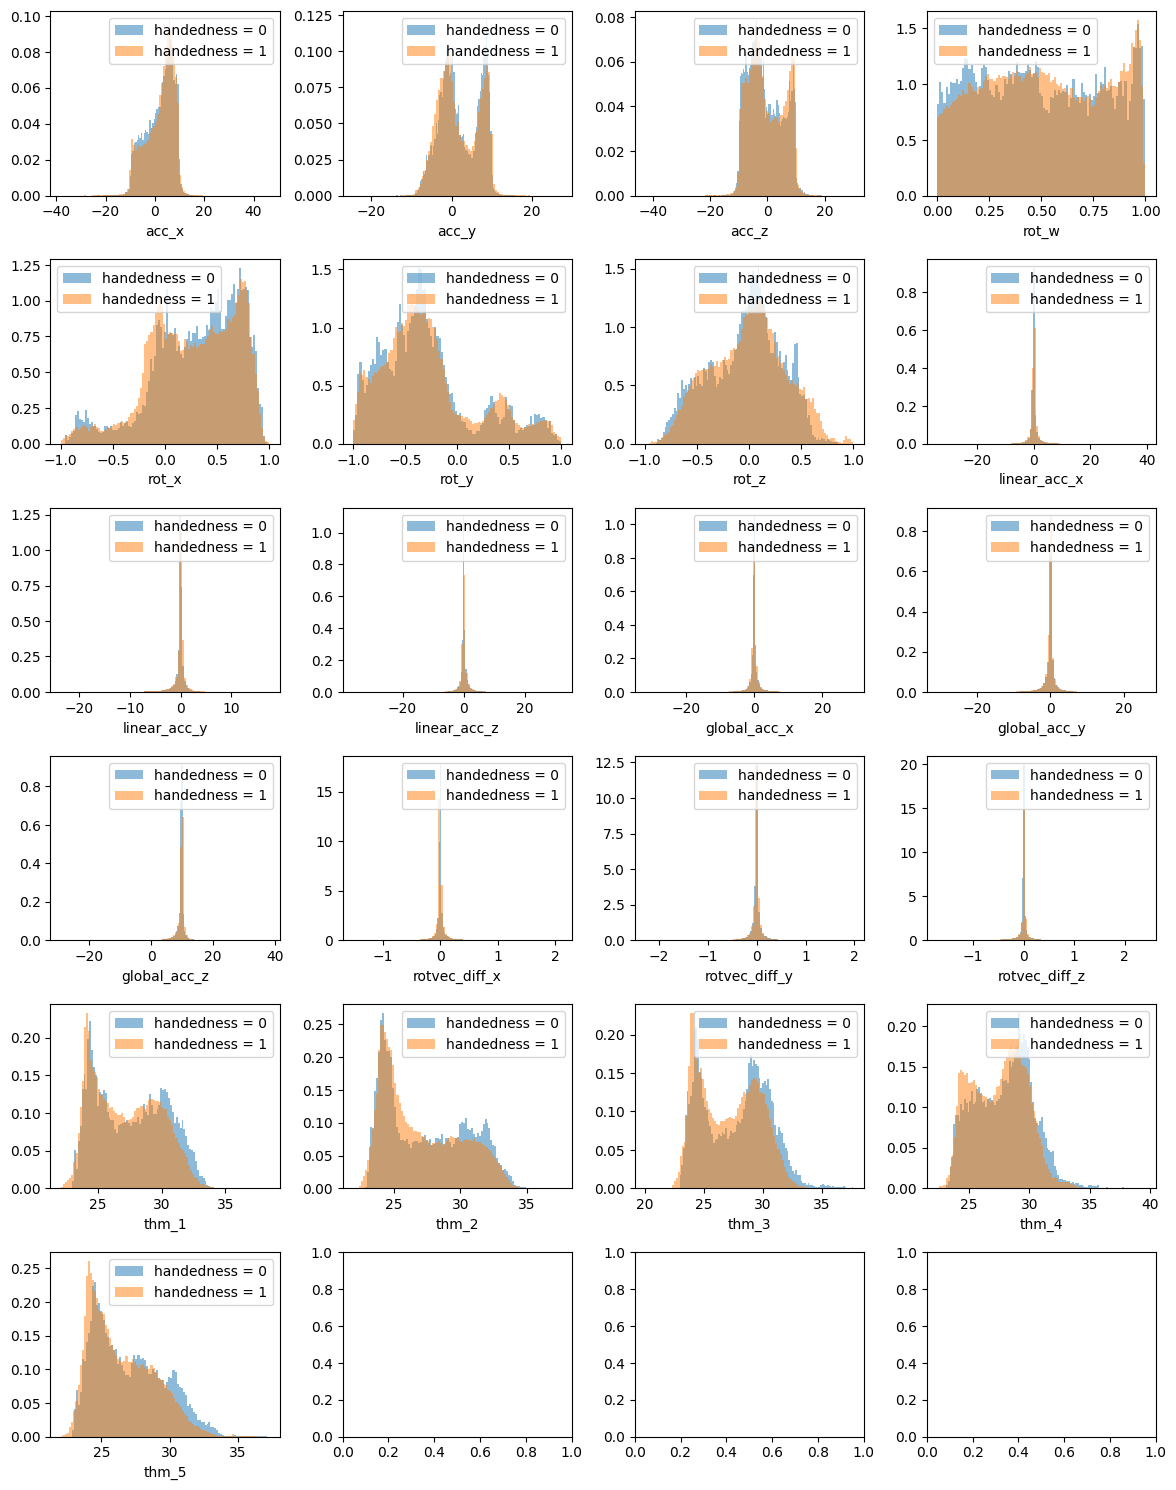

In [15]:
cols_fig = sum(feature_blocks_except_tof, [])
nrows = (len(cols_fig) + 3) // 4
fig, axes = plt.subplots(nrows=nrows, ncols=4, figsize=(12, nrows * 2.5))
axes = axes.flatten()
for i, col in enumerate(cols_fig):
    for j in range(2):
        axes[i].hist(
            df.filter(pl.col("handedness") == j).select(col),
            bins=100,
            density=True,
            alpha=0.5,
            label=f"handedness = {j}",
        )
    axes[i].set_xlabel(col)
    axes[i].legend()
fig.tight_layout()
plt.show()

## 2. Define NN classes and functions

In [16]:
class MyDataset(Dataset):
    def __init__(self, X, X_tof, Y=None):
        self.X = torch.FloatTensor(X)
        self.X_tof = torch.FloatTensor(X_tof)
        if Y is not None:
            self.Y = torch.LongTensor(Y)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        if "Y" in dir(self):
            return (self.X[idx], self.X_tof[idx], self.Y[idx])
        else:
            return (self.X[idx], self.X_tof[idx], torch.Tensor())

In [17]:
class TofBlock(nn.Module):
    def __init__(self, out_channels, kernel_size):
        super().__init__()

        self.layers = nn.Sequential(
            self.ConvReLUBN(in_channels=1, out_channels=out_channels, kernel_size=kernel_size),
            nn.MaxPool2d(kernel_size=2),
            self.ConvReLUBN(in_channels=out_channels, out_channels=out_channels, kernel_size=kernel_size),
            nn.MaxPool2d(kernel_size=2),
            self.ConvReLUBN(in_channels=out_channels, out_channels=out_channels, kernel_size=kernel_size),
            nn.MaxPool2d(kernel_size=2),
        )

    def forward(self, x):
        out = self.layers(x)
        return out

    # ----- inner class -----

    class ConvReLUBN(nn.Module):
        def __init__(self, in_channels, out_channels, kernel_size):
            super().__init__()

            self.layers = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size, padding="same"),
                nn.ReLU(),
                nn.BatchNorm2d(out_channels),
            )

        def forward(self, x):
            out = self.layers(x)
            return out


class CNN1dBranch(nn.Module):
    def __init__(
        self,
        input_channels,
        output_channels,
        initial_channels_per_feature,
        cnn1d_channels,
        cnn1d_kernel_size,
        mlp_dropout,
    ):
        super().__init__()

        self.initial_layers = self.ConvReLUBN(
            input_channels,
            input_channels * initial_channels_per_feature,
            cnn1d_kernel_size,
            groups=input_channels,
        )

        cnn1d_layers = nn.ModuleList()
        for i in range(len(cnn1d_channels)):
            if i == 0:
                in_channels = input_channels * initial_channels_per_feature
            else:
                in_channels = cnn1d_channels[i - 1]
            out_channels = cnn1d_channels[i]

            cnn1d_layers.append(self.ConvReLUBN(in_channels, out_channels, cnn1d_kernel_size))
            if i < len(cnn1d_channels) - 1:
                cnn1d_layers.append(nn.MaxPool1d(kernel_size=3, stride=3))
        self.cnn1d_layers = nn.Sequential(*cnn1d_layers)

        n_channels = cnn1d_channels[-1] * 2
        self.mlp = nn.Sequential(
            nn.Linear(n_channels, n_channels // 2),
            nn.ReLU(),
            nn.Dropout(mlp_dropout),
            nn.Linear(n_channels // 2, n_channels // 4),
            nn.ReLU(),
            nn.Dropout(mlp_dropout),
            nn.Linear(n_channels // 4, output_channels),
        )

    def forward(self, x, gesture_segment):
        x = self.initial_layers(x)
        x = self.cnn1d_layers(x)
        x1 = (x * (gesture_segment > 0)).sum(dim=2) / (gesture_segment > 0).sum(dim=2).clamp(min=1)
        x2 = (x * (gesture_segment < 0)).sum(dim=2) / (gesture_segment < 0).sum(dim=2).clamp(min=1)
        x = torch.cat([x1, x2], dim=1)
        out = self.mlp(x)
        return x, out

    # ----- inner class -----

    class ConvReLUBN(nn.Module):
        def __init__(self, in_channels, out_channels, kernel_size, stride=1, groups=1):
            super().__init__()

            if stride == 1:
                padding = "same"
            else:
                padding = (kernel_size - stride) // 2
            self.layers = nn.Sequential(
                nn.Conv1d(
                    in_channels,
                    out_channels,
                    kernel_size=kernel_size,
                    stride=stride,
                    padding=padding,
                    groups=groups,
                ),
                nn.ReLU(),
                nn.BatchNorm1d(out_channels),
            )

        def forward(self, x):
            out = self.layers(x)
            return out


class MultiBranchClassifier(nn.Module):
    def __init__(
        self,
        n_imu_blocks,
        input_channels,
        output_channels,
        initial_channels_per_feature,
        cnn1d_channels,
        cnn1d_kernel_size,
        tof_out_channels,
        tof_kernel_size,
        mlp_dropout,
    ):
        super().__init__()

        self.n_imu_blocks = n_imu_blocks
        self.block_idxes = [1] + [1 + sum(input_channels[: i + 1]) for i in range(len(input_channels))]
        self.cnn_branches = nn.ModuleList(
            [
                CNN1dBranch(
                    input_channels[i],
                    output_channels,
                    initial_channels_per_feature,
                    cnn1d_channels,
                    cnn1d_kernel_size,
                    mlp_dropout,
                )
                for i in range(len(input_channels))
            ]
            + [
                CNN1dBranch(
                    tof_out_channels * 5,
                    output_channels,
                    initial_channels_per_feature,
                    cnn1d_channels,
                    cnn1d_kernel_size,
                    mlp_dropout,
                )
            ]
        )
        self.tof_blocks = nn.ModuleList(
            [
                TofBlock(
                    out_channels=tof_out_channels,
                    kernel_size=tof_kernel_size,
                )
                for _ in range(5)
            ]
        )

        n_channels = cnn1d_channels[-1] * (len(input_channels) + 1) * 2
        self.mlp_all = nn.Sequential(
            nn.Linear(n_channels, n_channels // 2),
            nn.ReLU(),
            nn.Dropout(mlp_dropout),
            nn.Linear(n_channels // 2, n_channels // 4),
            nn.ReLU(),
            nn.Dropout(mlp_dropout),
            nn.Linear(n_channels // 4, output_channels),
        )
        self.ensemble_all = nn.Linear((len(input_channels) + 2) * output_channels, output_channels)

        n_channels = cnn1d_channels[-1] * self.n_imu_blocks * 2
        self.mlp_imu = nn.Sequential(
            nn.Linear(n_channels, n_channels // 2),
            nn.ReLU(),
            nn.Dropout(mlp_dropout),
            nn.Linear(n_channels // 2, n_channels // 4),
            nn.ReLU(),
            nn.Dropout(mlp_dropout),
            nn.Linear(n_channels // 4, output_channels),
        )
        self.ensemble_imu = nn.Linear(output_channels * (self.n_imu_blocks + 1), output_channels)

    def forward(self, x, x_tof):
        list_x = []
        list_out = []

        gesture_segment = F.avg_pool1d(x[:, :1], kernel_size=3, stride=3)
        for i in range(len(self.block_idxes) - 1):
            x_block = x[:, self.block_idxes[i] : self.block_idxes[i + 1]]
            x_block, out = self.cnn_branches[i](x_block, gesture_segment)
            list_x.append(x_block)
            list_out.append(out)

        list_x_tof = []
        for i in range(5):
            x_block = x_tof[:, :, i].reshape(-1, 1, 8, 8)
            out = self.tof_blocks[i](x_block)
            out = out.reshape(x.shape[0], -1, out.shape[1]).transpose(1, 2)
            list_x_tof.append(out)
        x_tof = torch.cat(list_x_tof, dim=1)
        x_tof, out = self.cnn_branches[-1](x_tof, gesture_segment)
        list_x.append(x_tof)
        list_out.append(out)

        x_all = torch.cat(list_x, dim=1)
        out_all = self.mlp_all(x_all)
        out_all = self.ensemble_all(torch.cat([out_all] + list_out, dim=1))

        x_imu = torch.cat(list_x[: self.n_imu_blocks], dim=1)
        out_imu = self.mlp_imu(x_imu)
        out_imu = self.ensemble_imu(torch.cat([out_imu] + list_out[: self.n_imu_blocks], dim=1))

        out = torch.stack([out_all, out_imu] + list_out, dim=1)
        return out

In [18]:
def train(model, data_loader, optimizer, criterion, device):
    model.train()
    optimizer.train()

    for batch in data_loader:
        X = batch[0].to(device)
        X_tof = batch[1].to(device)
        Y = batch[2].to(device)

        preds = model(X, X_tof)
        loss_weights = [1 / 4, 1 / 4] + [1 / (preds.shape[1] - 2) / 2] * (preds.shape[1] - 2)

        for i in range(preds.shape[1]):
            if i == 0:
                loss_main = criterion(preds[:, i, : len(all_gestures)], Y[:, 0]) * loss_weights[i]
                loss_aux = criterion(preds[:, i, len(all_gestures) :], Y[:, 1]) * loss_weights[i]
            else:
                loss_main += criterion(preds[:, i, : len(all_gestures)], Y[:, 0]) * loss_weights[i]
                loss_aux += criterion(preds[:, i, len(all_gestures) :], Y[:, 1]) * loss_weights[i]

        loss = loss_main + loss_aux * config.aux_loss_weight

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model.eval()
    optimizer.eval()


def predict(model, data_loader, device):
    preds_all = []
    for batch in data_loader:
        X = batch[0].to(device)
        X_tof = batch[1].to(device)

        with torch.inference_mode():
            preds = model(X, X_tof)[:, :, : len(all_gestures)]
        preds = preds.cpu().numpy()
        preds_all.append(preds)

    return np.concatenate(preds_all, axis=0)

In [19]:
def metric(y, preds):
    f1_binary = f1_score(y < len(target_gestures), np.argmax(preds, axis=1) < len(target_gestures), average="binary")
    f1_macro = f1_score(
        y.clip(max=len(target_gestures)), np.argmax(preds, axis=1).clip(max=len(target_gestures)), average="macro"
    )
    return (f1_binary + f1_macro) / 2

## 3. Train NN

In [20]:
%%time

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
sgkf = StratifiedGroupKFold(n_splits=config.n_splits, shuffle=True, random_state=0)
preds_oof = np.zeros((config.n_seeds, config.n_epochs, len(Y), len(feature_blocks_except_tof) + 3, len(all_gestures)))
for fold, (idx_train, idx_valid) in enumerate(sgkf.split(X, Y_main, groups)):
    X_train = X[idx_train]
    X_tof_train = X_tof[idx_train]
    Y_train = Y[idx_train]
    ds_train = MyDataset(X_train, X_tof_train, Y_train)
    dl_train = DataLoader(
        ds_train,
        batch_size=config.batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True,
        drop_last=True,
    )

    X_valid = X[idx_valid]
    X_tof_valid = X_tof[idx_valid]
    Y_valid = Y[idx_valid]
    ds_valid = MyDataset(X_valid, X_tof_valid, Y_valid)
    dl_valid = DataLoader(
        ds_valid,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
        drop_last=False,
    )

    for seed in range(config.n_seeds):
        seed_everything(seed)
        model = MultiBranchClassifier(
            n_imu_blocks=n_imu_blocks,
            input_channels=[len(features) for features in feature_blocks_except_tof],
            output_channels=len(all_gestures) + len(orientations),
            initial_channels_per_feature=16,
            cnn1d_channels=(256, 256),
            cnn1d_kernel_size=3,
            tof_out_channels=32,
            tof_kernel_size=3,
            mlp_dropout=0.3,
        )
        if fold == 0 and seed == 0:
            print(
                summary(
                    model=model,
                    input_size=(
                        (config.batch_size,) + X.shape[1:],
                        (config.batch_size,) + X_tof.shape[1:],
                    ),
                    col_names=["input_size", "output_size", "num_params"],
                    col_width=20,
                )
            )
        model.to(device)
        optimizer = RAdamScheduleFree(model.parameters(), lr=config.lr, betas=config.betas)
        criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)

        print(f"fold-seed: {fold}-{seed}")
        for epoch in range(config.n_epochs):
            train(model, dl_train, optimizer, criterion, device)
            preds_oof[seed, epoch, idx_valid] = predict(model, dl_valid, device)
            if epoch >= config.n_epochs - 5:
                torch.save(model.state_dict(), f"{MODEL_DIR}/model_{fold}_{seed}_{epoch}.pth")

Layer (type:depth-idx)                             Input Shape          Output Shape         Param #
MultiBranchClassifier                              [32, 22, 75]         [32, 8, 22]          --
├─ModuleList: 1-3                                  --                   --                   (recursive)
│    └─CNN1dBranch: 2-1                            [32, 3, 75]          [32, 512]            --
│    │    └─ConvReLUBN: 3-1                        [32, 3, 75]          [32, 48, 75]         288
│    │    └─Sequential: 3-2                        [32, 48, 75]         [32, 256, 25]        235,008
│    │    └─Sequential: 3-3                        [32, 512]            [32, 22]             167,062
│    └─CNN1dBranch: 2-2                            [32, 4, 75]          [32, 512]            --
│    │    └─ConvReLUBN: 3-4                        [32, 4, 75]          [32, 64, 75]         384
│    │    └─Sequential: 3-5                        [32, 64, 75]         [32, 256, 25]        247,296
│    │   

In [21]:
np.save(f"{OUTPUT_DIR}/preds_oof.npy", preds_oof)

## 4. Evaluation

In [22]:
list_scores = [[] for _ in range(preds_oof.shape[3])]
best_epoch = 0
best_score = 0
for epoch in range(config.n_epochs):
    print(f"epoch: {str(epoch).zfill(2)}   score:", end="")
    for i in range(config.n_seeds):
        preds = preds_oof[: i + 1, epoch].mean(axis=0)
        scores = [metric(Y_main, preds[:, i]) for i in range(preds.shape[1])]
        print(f"   {scores[0]:.4f} {scores[1]:.4f}", end="")
    for i in range(preds.shape[1]):
        list_scores[i].append(scores[i])
    if (scores[0] + scores[1]) / 2 > best_score:
        best_score = (scores[0] + scores[1]) / 2
        best_epoch = epoch
        best_preds = preds_oof[:, epoch].mean(axis=0)
        print(" best!", end="")
    print()

epoch: 00   score:   0.8519 0.7644   0.8652 0.7733   0.8665 0.7800   0.8702 0.7804   0.8720 0.7836 best!
epoch: 01   score:   0.8733 0.7989   0.8831 0.8061   0.8850 0.8090   0.8842 0.8112   0.8860 0.8115 best!
epoch: 02   score:   0.8835 0.8090   0.8900 0.8163   0.8935 0.8208   0.8931 0.8193   0.8928 0.8200 best!
epoch: 03   score:   0.8902 0.8202   0.8926 0.8244   0.8964 0.8248   0.8965 0.8262   0.8955 0.8281 best!
epoch: 04   score:   0.8888 0.8243   0.8963 0.8302   0.8982 0.8338   0.8996 0.8351   0.8999 0.8342 best!
epoch: 05   score:   0.8900 0.8268   0.8988 0.8315   0.9007 0.8361   0.9002 0.8374   0.9016 0.8361 best!
epoch: 06   score:   0.8866 0.8257   0.8967 0.8319   0.8994 0.8361   0.8998 0.8372   0.8990 0.8368
epoch: 07   score:   0.8890 0.8255   0.8984 0.8320   0.8997 0.8364   0.9016 0.8366   0.9025 0.8371 best!
epoch: 08   score:   0.8915 0.8271   0.8999 0.8358   0.9016 0.8373   0.9017 0.8399   0.9020 0.8399 best!
epoch: 09   score:   0.8892 0.8275   0.8985 0.8357   0.9022 0

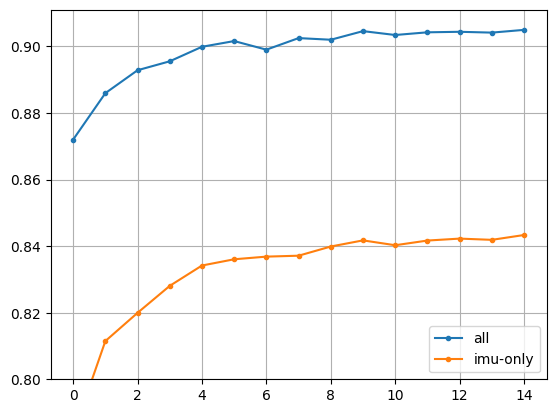

In [23]:
plt.plot(list_scores[0], marker=".", label="all")
plt.plot(list_scores[1], marker=".", label="imu-only")
plt.ylim(bottom=0.80)
plt.grid()
plt.legend()
plt.show()

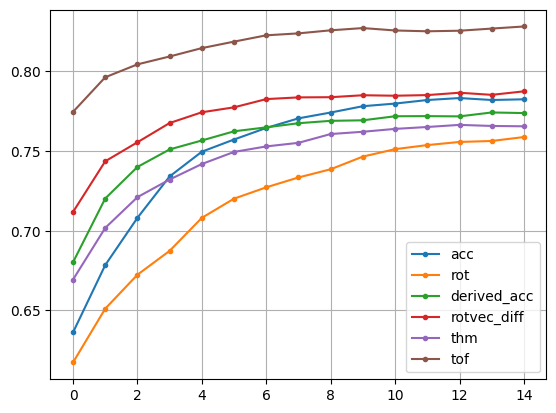

In [24]:
preds_names = ["all", "imu", "acc", "rot", "derived_acc", "rotvec_diff", "thm", "tof"]
for i, list_score in enumerate(list_scores[2:]):
    plt.plot(list_score, marker=".", label=preds_names[2:][i])
plt.grid()
plt.legend()
plt.show()

In [25]:
preds = best_preds
preds = np.exp(preds) / np.exp(preds).sum(axis=-1, keepdims=True)

In [26]:
df_pred = (
    df.select(["subject", "handedness", "rotate", "sequence_id"])
    .unique(maintain_order=True)
    .with_columns(
        pl.lit(Y_main).alias("target"),
        *[pl.lit(np.argmax(preds[:, i], axis=-1)).alias(f"pred_{preds_names[i]}") for i in range(preds.shape[1])],
    )
)

In [27]:
with pl.Config(tbl_rows=-1):
    display(
        df_pred.with_columns(
            [
                (pl.col("target") == pl.col(f"pred_{preds_names[i]}")).alias(f"acc_{preds_names[i]}")
                for i in range(preds.shape[1])
            ],
        )
        .group_by(["handedness", "rotate"])
        .agg(
            pl.col("subject").n_unique(),
            pl.col("sequence_id").n_unique(),
            pl.col("^acc.*$").mean().round(2),
        )
        .sort("sequence_id", descending=True)
    )

handedness,rotate,subject,sequence_id,acc_all,acc_imu,acc_acc,acc_rot,acc_derived_acc,acc_rotvec_diff,acc_thm,acc_tof
i64,i16,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64
1,0,69,6927,0.85,0.77,0.67,0.62,0.65,0.68,0.62,0.7
0,0,10,1020,0.84,0.77,0.67,0.65,0.67,0.67,0.59,0.64
1,1,2,204,0.92,0.73,0.63,0.62,0.67,0.66,0.55,0.74


In [28]:
with pl.Config(tbl_rows=-1):
    display(
        df_pred.with_columns(
            [
                (pl.col("target") == pl.col(f"pred_{preds_names[i]}")).alias(f"acc_{preds_names[i]}")
                for i in range(preds.shape[1])
            ],
        )
        .group_by(["subject", "handedness", "rotate"])
        .agg(
            pl.col("sequence_id").n_unique(),
            pl.col("^acc.*$").mean().round(2),
        )
        .sort("subject")
    )


subject,handedness,rotate,sequence_id,acc_all,acc_imu,acc_acc,acc_rot,acc_derived_acc,acc_rotvec_diff,acc_thm,acc_tof
str,i64,i16,u32,f64,f64,f64,f64,f64,f64,f64,f64
"""SUBJ_000206""",1,0,102,0.88,0.75,0.65,0.74,0.62,0.72,0.6,0.75
"""SUBJ_001430""",1,0,102,0.92,0.86,0.66,0.64,0.76,0.72,0.65,0.73
"""SUBJ_002923""",0,0,102,0.79,0.79,0.79,0.7,0.7,0.67,0.52,0.57
"""SUBJ_003328""",1,0,102,0.89,0.85,0.75,0.74,0.83,0.7,0.66,0.75
"""SUBJ_004117""",1,0,102,0.95,0.86,0.81,0.7,0.82,0.85,0.71,0.82
"""SUBJ_008304""",1,0,102,0.73,0.71,0.63,0.6,0.57,0.56,0.57,0.5
"""SUBJ_008728""",1,0,102,0.91,0.84,0.79,0.64,0.8,0.77,0.74,0.76
"""SUBJ_011323""",1,0,101,0.66,0.72,0.65,0.55,0.51,0.65,0.1,0.12
"""SUBJ_012088""",1,0,102,0.97,0.77,0.74,0.74,0.73,0.64,0.68,0.79


In [29]:
with pl.Config(tbl_rows=-1):
    display(
        df_pred.with_columns(
            [
                (pl.col("target") == pl.col(f"pred_{preds_names[i]}")).alias(f"acc_{preds_names[i]}")
                for i in range(preds.shape[1])
            ],
        )
        .group_by(pl.all().exclude(["sequence_id", "target", "^pred.*$", "^acc.*$"]))
        .agg(
            pl.col("sequence_id").n_unique(),
            pl.col("^acc.*$").mean().round(2),
        )
        .sort("acc_all", descending=True)
    )

subject,handedness,rotate,sequence_id,acc_all,acc_imu,acc_acc,acc_rot,acc_derived_acc,acc_rotvec_diff,acc_thm,acc_tof
str,i64,i16,u32,f64,f64,f64,f64,f64,f64,f64,f64
"""SUBJ_039498""",1,0,102,0.99,0.82,0.69,0.73,0.75,0.75,0.73,0.88
"""SUBJ_026460""",1,0,102,0.98,0.85,0.77,0.72,0.73,0.78,0.66,0.8
"""SUBJ_012088""",1,0,102,0.97,0.77,0.74,0.74,0.73,0.64,0.68,0.79
"""SUBJ_004117""",1,0,102,0.95,0.86,0.81,0.7,0.82,0.85,0.71,0.82
"""SUBJ_053217""",1,0,54,0.94,0.72,0.78,0.63,0.59,0.59,0.56,0.72
"""SUBJ_017807""",1,0,102,0.93,0.87,0.7,0.7,0.69,0.73,0.7,0.71
"""SUBJ_040282""",1,0,102,0.92,0.85,0.75,0.71,0.71,0.73,0.7,0.75
"""SUBJ_001430""",1,0,102,0.92,0.86,0.66,0.64,0.76,0.72,0.65,0.73
"""SUBJ_019262""",1,1,102,0.92,0.68,0.6,0.58,0.66,0.62,0.61,0.77


In [30]:
with pl.Config(tbl_rows=-1):
    display(
        df_pred.with_columns(
            [
                (pl.col("target") == pl.col(f"pred_{preds_names[i]}")).alias(f"acc_{preds_names[i]}")
                for i in range(preds.shape[1])
            ],
        )
        .group_by("target")
        .agg(
            pl.col("subject").n_unique(),
            pl.col("sequence_id").n_unique(),
            pl.col("^acc.*$").mean().round(2),
        )
        .sort("target")
    )

target,subject,sequence_id,acc_all,acc_imu,acc_acc,acc_rot,acc_derived_acc,acc_rotvec_diff,acc_thm,acc_tof
i8,u32,u32,f64,f64,f64,f64,f64,f64,f64,f64
0,81,638,0.89,0.67,0.56,0.59,0.53,0.59,0.73,0.82
1,81,637,0.79,0.59,0.47,0.44,0.41,0.46,0.43,0.64
2,81,638,0.65,0.46,0.39,0.29,0.35,0.37,0.36,0.53
3,81,640,0.68,0.6,0.53,0.54,0.54,0.54,0.46,0.55
4,81,640,0.8,0.69,0.57,0.57,0.57,0.57,0.58,0.72
5,81,640,0.92,0.88,0.73,0.75,0.72,0.76,0.71,0.76
6,81,640,0.75,0.61,0.44,0.33,0.45,0.5,0.39,0.53
7,81,640,0.83,0.75,0.59,0.46,0.6,0.62,0.49,0.56
8,81,161,0.88,0.85,0.69,0.41,0.71,0.71,0.5,0.65


In [31]:
pd.crosstab(df_pred["pred_all"].to_pandas(), df_pred["target"].to_pandas())

target,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
pred_all,,,,,,,,,,,,,,,,,,
0,569,9,12,11,14,1,25,5,0,0,0,0,0,0,0,1,0,0
1,15,506,26,41,2,2,63,15,0,0,1,0,1,0,0,0,0,1
2,14,23,413,117,63,24,1,0,0,0,0,0,0,1,0,0,0,0
3,5,35,101,435,1,4,4,2,0,0,0,0,0,0,0,0,0,0
4,6,2,47,11,514,17,1,0,0,0,0,0,0,0,0,0,0,0
5,2,2,30,12,37,588,0,4,0,0,0,0,0,0,2,0,0,0
6,13,40,2,3,0,0,480,81,0,0,0,0,0,0,0,0,0,0
7,13,18,3,5,1,2,66,532,0,0,0,0,0,0,0,0,0,1
8,0,0,0,0,0,0,0,0,141,0,0,0,0,0,21,0,0,14


In [32]:
pd.crosstab(df_pred["pred_imu"].to_pandas(), df_pred["target"].to_pandas())

target,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
pred_imu,,,,,,,,,,,,,,,,,,
0,429,21,4,11,26,1,76,28,0,3,0,0,3,0,0,1,0,0
1,32,375,79,46,28,11,78,15,0,1,0,0,0,2,0,1,0,0
2,15,57,293,127,73,12,8,7,0,0,0,0,0,0,0,0,0,1
3,8,46,126,387,11,11,15,4,0,0,0,1,0,0,0,0,0,0
4,28,37,62,22,439,19,7,4,0,1,0,0,3,0,0,0,0,0
5,2,9,32,18,41,565,1,31,1,0,0,0,0,0,0,0,0,0
6,68,69,19,14,6,1,392,60,0,1,0,1,1,0,0,0,0,1
7,48,20,17,7,8,16,59,483,0,0,0,1,1,0,2,0,0,0
8,0,0,0,0,0,0,0,0,137,0,0,0,0,0,20,0,0,9
